In [1]:
from adam_impact_study.types import (
    ImpactorOrbits,
    Observations,
    ResultsTiming,
    WindowResult,
    ImpactorResultSummary,
)
import pyarrow.compute as pc
import numpy as np
import quivr as qv
import ray
from adam_impact_study.analysis.main import (
    run_all_analysis,
    collect_all_results,
    summarize_impact_study_results,
    make_analysis_plots,
    calculate_completeness,
)
from adam_impact_study.analysis.collect import (
    collect_all_window_results_new,
    create_missing_window_results,
    collect_all_observations,
)

In [2]:
ray.shutdown()

In [3]:
from pathlib import Path

run_dir = "/Users/kathleenkiker/impacts_paper/adam_impacts_study/data/mar_run"
out_dir = "/Users/kathleenkiker/impacts_paper/adam_impacts_study/data/mar_run_analysis_20260301/"

# If True, regenerate analysis parquet outputs from run_dir.
# If False, reuse existing files in out_dir.
REBUILD_ANALYSIS_PRODUCTS = False
MAX_PROCESSES = 1

Path(out_dir).mkdir(parents=True, exist_ok=True)

In [4]:
if REBUILD_ANALYSIS_PRODUCTS:
    impactor_orbits, observations, results_timing, window_results = collect_all_results(
        run_dir, max_processes=MAX_PROCESSES
    )

In [5]:
if REBUILD_ANALYSIS_PRODUCTS:
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    impactor_orbits.to_parquet(Path(out_dir) / "impactor_orbits.parquet")
    observations.to_parquet(Path(out_dir) / "observations.parquet")
    results_timing.to_parquet(Path(out_dir) / "results_timing.parquet")
    window_results.to_parquet(Path(out_dir) / "window_results.parquet")

In [6]:
required_files = [
    Path(out_dir) / "impactor_orbits.parquet",
    Path(out_dir) / "observations.parquet",
    Path(out_dir) / "results_timing.parquet",
    Path(out_dir) / "window_results.parquet",
]
missing_files = [str(p) for p in required_files if not p.exists()]
if missing_files:
    raise RuntimeError(
        "Missing analysis products. Set REBUILD_ANALYSIS_PRODUCTS=True and run from top.\n"
        f"out_dir={Path(out_dir).resolve()}\n"
        f"missing={missing_files}"
    )

impactor_orbits = ImpactorOrbits.from_parquet(required_files[0])
observations = Observations.from_parquet(required_files[1])
results_timing = ResultsTiming.from_parquet(required_files[2])
window_results = WindowResult.from_parquet(required_files[3])


In [ ]:
if REBUILD_ANALYSIS_PRODUCTS:
    summary_results = summarize_impact_study_results(
        impactor_orbits,
        observations,
        results_timing,
        window_results,
        out_dir,
        max_processes=MAX_PROCESSES,
    )
    summary_results.to_parquet(Path(out_dir) / "summary_results.parquet")

In [8]:
summary_results_file = Path(out_dir) / "summary_results.parquet"
if not summary_results_file.exists():
    raise RuntimeError(
        "Missing summary_results.parquet. Set REBUILD_ANALYSIS_PRODUCTS=True and run from top, "
        f"or point out_dir at existing products. Missing: {summary_results_file}"
    )

summary_results = ImpactorResultSummary.from_parquet(summary_results_file)



In [9]:
# select prograde summary
summary_results_no_retrograde = summary_results.apply_mask(summary_results.prograde_orbits())


In [ ]:
# Ensure expected plot output subdirectories exist.
for subdir in [
    "no_retrograde",
    "individuals_observed_not_discovered",
    "individuals_a_sub_1",
]:
    (Path(out_dir) / subdir).mkdir(parents=True, exist_ok=True)

In [10]:
from adam_impact_study.analysis.plots import plot_discovered_by_diameter_impact_period
from adam_core.time import Timestamp
import os
import matplotlib.pyplot as plt

fig, ax = plot_discovered_by_diameter_impact_period(
    summary_results_no_retrograde,
    period="5year",
    max_impact_time=Timestamp.from_iso8601(["2070-01-01"]),
    time_before_impact_limit_days=365 * 5.0
)
fig.savefig(
    os.path.join(out_dir+"no_retrograde/", "discovered_by_diameter_5year_2070_5yrimpact.jpg"),
    bbox_inches="tight",
    dpi=200,
)
plt.close(fig)

/Users/natetellis/code/adam_impacts_study/.venv/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/natetellis/code/adam_impacts_study/.venv/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
INFO:adam_impact_study.analysis.plots:Filtering 27881 objects that impact before ['2070-01-01 00:00:00.000']
INFO:adam_impact_study.analysis.plots:After filtering, 12314 objects remain


In [ ]:
# Ensure expected plot output subdirectories exist.
for subdir in [
    "no_retrograde",
    "individuals_observed_not_discovered",
    "individuals_a_sub_1",
]:
    (Path(out_dir) / subdir).mkdir(parents=True, exist_ok=True)

In [11]:
# make_analysis_plots(summary_results_no_retrograde, window_results, out_dir+"no_retrograde/")



In [ ]:
from adam_impact_study.analysis.plots import plot_individual_orbit_ip_over_time
# Reload the plot_individual_orbit_ip_over_time function to ensure we have the latest version
import importlib
from adam_impact_study.analysis import plots
importlib.reload(plots)
from adam_impact_study.analysis.plots import plot_individual_orbit_ip_over_time


observed_not_discovered_summary = summary_results.apply_mask(summary_results.observed_but_not_discovered())
orbit_ids = observed_not_discovered_summary.orbit.orbit_id
impactor_orbits_observed_not_discovered = impactor_orbits.apply_mask(pc.is_in(impactor_orbits.orbit_id, orbit_ids))

window_results_observed_not_discovered = window_results.apply_mask(pc.is_in(window_results.orbit_id, orbit_ids))

plot_individual_orbit_ip_over_time(impactor_orbits_observed_not_discovered, window_results_observed_not_discovered, out_dir+"individuals_observed_not_discovered/", summary_results=observed_not_discovered_summary, plot_discovery_time_optimistic=True)

In [ ]:
from adam_impact_study.analysis.plots import plot_individual_orbit_ip_over_time
# Reload the plot_individual_orbit_ip_over_time function to ensure we have the latest version
import importlib
from adam_impact_study.analysis import plots
importlib.reload(plots)
from adam_impact_study.analysis.plots import plot_individual_orbit_ip_over_time


coords = impactor_orbits.coordinates.to_keplerian()
coords_twilight_mask = pc.and_(
    pc.less(coords.i, 5),
    pc.less(coords.a, 0.9),
)
orbit_ids_twilight = impactor_orbits.apply_mask(coords_twilight_mask).orbit_id

observed_not_discovered_summary = summary_results.apply_mask(pc.is_in(summary_results.orbit.orbit_id, orbit_ids_twilight))

impactor_orbits_observed_not_discovered = impactor_orbits.apply_mask(pc.is_in(impactor_orbits.orbit_id, orbit_ids_twilight))

window_results_observed_not_discovered = window_results.apply_mask(pc.is_in(window_results.orbit_id, orbit_ids_twilight))

plot_individual_orbit_ip_over_time(impactor_orbits_observed_not_discovered, window_results_observed_not_discovered, out_dir+"individuals_a_sub_1/", summary_results=observed_not_discovered_summary, plot_discovery_time_optimistic=True)

In [ ]:
# Individual IP-over-time plots for 1 km objects

one_km_dir = Path(out_dir) / "individuals_1km"
one_km_dir.mkdir(parents=True, exist_ok=True)

one_km_mask = pc.equal(impactor_orbits.diameter, 1.0)
one_km_orbit_ids = impactor_orbits.apply_mask(one_km_mask).orbit_id

one_km_impactor_orbits = impactor_orbits.apply_mask(
    pc.is_in(impactor_orbits.orbit_id, one_km_orbit_ids)
)
one_km_window_results = window_results.apply_mask(
    pc.is_in(window_results.orbit_id, one_km_orbit_ids)
)
one_km_summary = summary_results.apply_mask(
    pc.is_in(summary_results.orbit.orbit_id, one_km_orbit_ids)
)

print(f"1km objects: {len(one_km_impactor_orbits)} orbits, {len(one_km_window_results)} windows")
if len(one_km_impactor_orbits) == 0:
    raise RuntimeError("No 1 km objects found in impactor_orbits.")

plot_individual_orbit_ip_over_time(
    one_km_impactor_orbits,
    one_km_window_results,
    str(one_km_dir) + "/",
    summary_results=one_km_summary,
    plot_discovery_time_optimistic=True,
)

In [43]:
orbit_id = "I00280_b011_v000000_2035-2045"

from adam_core.orbits.plots import plot_orbit
from adam_assist import ASSISTPropagator

plot_orbit(impactor_orbits.select("orbit_id", orbit_id).orbits(), ASSISTPropagator(), start_time=Timestamp.from_iso8601(["2025-01-01"]))




In [ ]:
unobserved = summary_results.apply_mask(pc.equal(summary_results.observations, 0))

coords = unobserved.orbit.coordinates.to_keplerian()
coords_twilight_mask = pc.and_(
    pc.less(coords.i, 10),
    pc.less(coords.a, 0.9),
)
unobserved_twilight_summary = unobserved.apply_mask(coords_twilight_mask)
big = unobserved_twilight_summary.apply_mask(pc.equal(unobserved_twilight_summary.orbit.diameter, 1.0))
big.to_dataframe()

,orbit.orbit_id,orbit.object_id,orbit.coordinates.x,orbit.coordinates.y,orbit.coordinates.z,orbit.coordinates.vx,orbit.coordinates.vy,orbit.coordinates.vz,orbit.coordinates.time.days,orbit.coordinates.time.nanos,...,results_timing.orbit_id,results_timing.sorcha_runtime,results_timing.mean_od_runtime,results_timing.total_od_runtime,results_timing.mean_ip_runtime,results_timing.total_ip_runtime,results_timing.mean_window_runtime,results_timing.total_window_runtime,results_timing.total_runtime,status
0,I00470_b011_v000000_2025-2035,I00470,0.873202,0.588219,-0.023123,-0.008483,0.010993,0.000708,60969,18790086212754,...,I00470_b011_v000000_2025-2035,9.408181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete
1,I00088_b011_v000000_2025-2035,I00088,0.915490,0.526564,-0.026612,-0.007006,0.010926,0.000815,61328,71214262573421,...,I00088_b011_v000000_2025-2035,43.781837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete
2,I00396_b011_v000000_2025-2035,I00396,-0.149900,0.932909,-0.043238,-0.016220,-0.000345,0.001292,61037,19213534086943,...,I00396_b011_v000000_2025-2035,17.718898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete
3,I00476_b011_v000000_2025-2035,I00476,-0.974169,0.465882,-0.026710,-0.004362,-0.012106,0.000824,61086,16750875547528,...,I00476_b011_v000000_2025-2035,24.883229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete
4,I00177_b011_v000000_2085-2095,I00177,0.188670,0.788848,-0.025986,-0.011227,0.011699,0.000737,86213,12276230898499,...,I00177_b011_v000000_2085-2095,379.573878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete


In [58]:
orbit_id = "I00177_b011_v000000_2085-2095"

from adam_core.orbits.plots import plot_orbit
from adam_assist import ASSISTPropagator

plot_orbit(impactor_orbits.select("orbit_id", orbit_id).orbits(), ASSISTPropagator(), start_time=Timestamp.from_iso8601(["2025-01-01"]))

In [56]:
impactor_orbits.select("orbit_id", "I00341_b011_v000000_2025-2035").coordinates.to_keplerian().to_dataframe()

,a,e,i,raan,ap,M,time.days,time.nanos,covariance.values,origin.code
0,0.831721,0.321664,3.107417,316.015228,145.352403,201.604447,62326,63390291653574,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",SUN


In [15]:
summary_results.to_dataframe().columns

Index(['orbit.orbit_id', 'orbit.object_id', 'orbit.coordinates.x',
       'orbit.coordinates.y', 'orbit.coordinates.z', 'orbit.coordinates.vx',
       'orbit.coordinates.vy', 'orbit.coordinates.vz',
       'orbit.coordinates.time.days', 'orbit.coordinates.time.nanos',
       'orbit.coordinates.covariance.values', 'orbit.coordinates.origin.code',
       'orbit.impact_time.days', 'orbit.impact_time.nanos',
       'orbit.dynamical_class', 'orbit.ast_class', 'orbit.diameter',
       'orbit.albedo', 'orbit.H_r', 'orbit.u_r', 'orbit.g_r', 'orbit.i_r',
       'orbit.z_r', 'orbit.y_r', 'orbit.GS', 'mean_impact_time.days',
       'mean_impact_time.nanos', 'windows', 'nights', 'observations',
       'singletons', 'tracklets', 'first_observation.days',
       'first_observation.nanos', 'last_observation.days',
       'last_observation.nanos', 'discovery_time.days', 'discovery_time.nanos',
       'discovery_time_optimistic.days', 'discovery_time_optimistic.nanos',
       'ip_at_discovery_time', 'i

In [121]:
undiscovered_summary=summary_results.apply_mask(summary_results.observed_but_not_discovered())

In [122]:
undiscovered_summary.to_dataframe()

,orbit.orbit_id,orbit.object_id,orbit.coordinates.x,orbit.coordinates.y,orbit.coordinates.z,orbit.coordinates.vx,orbit.coordinates.vy,orbit.coordinates.vz,orbit.coordinates.time.days,orbit.coordinates.time.nanos,...,results_timing.orbit_id,results_timing.sorcha_runtime,results_timing.mean_od_runtime,results_timing.total_od_runtime,results_timing.mean_ip_runtime,results_timing.total_ip_runtime,results_timing.mean_window_runtime,results_timing.total_window_runtime,results_timing.total_runtime,status
0,I00165_b005_v000000_2095-2105,I00165,-0.039758,-1.061951,-0.022476,0.019257,0.002274,0.000696,87513,36557725587487,...,I00165_b005_v000000_2095-2105,490.112555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete
1,I00394_b005_v000000_2055-2065,I00394,-0.756807,-0.144548,-0.159972,-0.002616,-0.022767,0.004495,75019,5359313558042,...,I00394_b005_v000000_2055-2065,400.189816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete
2,I00103_b007_v000000_2075-2085,I00103,0.966502,-0.203216,-0.020482,0.002618,0.020466,0.000614,82851,15263035739958,...,I00103_b007_v000000_2075-2085,532.398853,4.047981,125.487424,9639.319631,289179.588933,9643.465960,289303.978790,105158.614888,complete
3,I00366_b005_v000000_2045-2055,I00366,-1.159956,0.156928,-0.314122,0.002764,-0.012263,0.009864,70964,27868041278422,...,I00366_b005_v000000_2045-2055,393.274958,1.588850,1.588850,375.539147,375.539147,377.132241,377.132241,773.055729,complete
4,I00099_b002_v000000_2025-2035,I00099,0.855467,-0.269148,-0.001979,0.008004,0.019548,0.000057,62391,71079453045130,...,I00099_b002_v000000_2025-2035,220.428134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6527,I00420_b002_v000000_2115-2125,I00420,1.035902,0.296039,-0.008227,-0.010304,0.017791,0.000244,96027,39740525302291,...,I00420_b002_v000000_2115-2125,395.683274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,complete
6528,I00009_b007_v000000_2025-2035,I00009,1.184564,0.415059,-0.053548,-0.013675,0.011477,0.001686,63149,11282354615629,...,I00009_b007_v000000_2025-2035,291.205598,2.250501,6.751503,141.473205,424.419616,143.730076,431.190227,445.756544,complete
6529,I00299_b008_v000000_2045-2055,I00299,-0.898034,-0.200986,-0.198014,0.000724,-0.017714,0.005920,69899,15814905126393,...,I00299_b008_v000000_2045-2055,389.063443,0.722553,0.722553,77.589760,77.589760,78.317064,78.317064,470.582006,complete
6530,I00096_b008_v000000_2035-2045,I00096,-0.221420,0.589522,-0.155970,-0.027522,-0.000076,0.003884,66179,61129882027209,...,I00096_b008_v000000_2035-2045,422.048135,3.157609,75.782606,150.515197,3612.364717,153.680115,3688.322749,1192.767712,complete


In [123]:
undiscovered_summary

ImpactorResultSummary(size=6532)

In [124]:
udiscovered_but_6_obs_in_30_days=undiscovered_summary.apply_mask(pc.greater(undiscovered_summary.observations, 5))

In [125]:
udiscovered_but_6_obs_in_30_days.observations.to_numpy()

array([51,  6, 13, ..., 11,  7, 41], dtype=uint64)

In [126]:
discoverable_with_6_obs_in_30_days = []
for orb in udiscovered_but_6_obs_in_30_days:
    id = orb.orbit.orbit_id
    obs = observations.apply_mask(pc.equal(observations.orbit_id, id[0]))
    obs_mjds = obs.coordinates.time.mjd().sort().to_numpy()
    # check if any observation is within 30 days of the observation 7 indices ahead of it
    # Vectorized approach using numpy
    if len(obs_mjds) >= 6:  # Need at least 6 observations to have 6 in 30 days
        # Calculate differences between observations that are 6 apart
        diffs = obs_mjds[5:] - obs_mjds[:-5]
        # If any difference is <= 30 days and >= 1 day, add to discoverable list
        if np.any((diffs <= 30) & (diffs >= 1)):
            discoverable_with_6_obs_in_30_days.append(orb)




In [127]:
discoverable_with_6_obs_in_30_days = qv.concatenate(discoverable_with_6_obs_in_30_days)

In [128]:
discoverable_with_6_obs_in_30_days

ImpactorResultSummary(size=2520)

In [26]:
observations.to_dataframe().columns

Index(['obs_id', 'orbit_id', 'coordinates.rho', 'coordinates.lon',
       'coordinates.lat', 'coordinates.vrho', 'coordinates.vlon',
       'coordinates.vlat', 'coordinates.time.days', 'coordinates.time.nanos',
       'coordinates.covariance.values', 'coordinates.origin.code',
       'observers.code', 'observers.coordinates.x', 'observers.coordinates.y',
       'observers.coordinates.z', 'observers.coordinates.vx',
       'observers.coordinates.vy', 'observers.coordinates.vz',
       'observers.coordinates.time.days', 'observers.coordinates.time.nanos',
       'observers.coordinates.covariance.values',
       'observers.coordinates.origin.code', 'photometry.mag',
       'photometry.mag_sigma', 'photometry.filter', 'observing_night',
       'linked'],
      dtype='object')

In [129]:
# discoverable_with_6_obs_in_30_days.to_dataframe()
# Display all columns in the DataFrame without truncation
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Show the full DataFrame with all columns
discoverable_with_6_obs_in_30_days.to_dataframe()



,orbit.orbit_id,orbit.object_id,orbit.coordinates.x,orbit.coordinates.y,orbit.coordinates.z,orbit.coordinates.vx,orbit.coordinates.vy,orbit.coordinates.vz,orbit.coordinates.time.days,orbit.coordinates.time.nanos,orbit.coordinates.covariance.values,orbit.coordinates.origin.code,orbit.impact_time.days,orbit.impact_time.nanos,orbit.dynamical_class,orbit.ast_class,orbit.diameter,orbit.albedo,orbit.H_r,orbit.u_r,orbit.g_r,orbit.i_r,orbit.z_r,orbit.y_r,orbit.GS,mean_impact_time.days,mean_impact_time.nanos,windows,nights,observations,singletons,tracklets,first_observation.days,first_observation.nanos,last_observation.days,last_observation.nanos,discovery_time.days,discovery_time.nanos,discovery_time_optimistic.days,discovery_time_optimistic.nanos,ip_at_discovery_time,ip_threshold_0_dot_01_percent.days,ip_threshold_0_dot_01_percent.nanos,ip_threshold_1_percent.days,ip_threshold_1_percent.nanos,ip_threshold_10_percent.days,ip_threshold_10_percent.nanos,ip_threshold_50_percent.days,ip_threshold_50_percent.nanos,ip_threshold_90_percent.days,ip_threshold_90_percent.nanos,ip_threshold_100_percent.days,ip_threshold_100_percent.nanos,maximum_impact_probability,maximum_impact_probability_5_years_prior,error,results_timing.orbit_id,results_timing.sorcha_runtime,results_timing.mean_od_runtime,results_timing.total_od_runtime,results_timing.mean_ip_runtime,results_timing.total_ip_runtime,results_timing.mean_window_runtime,results_timing.total_window_runtime,results_timing.total_runtime,status
0,I00103_b007_v000000_2075-2085,I00103,0.966502,-0.203216,-0.020482,0.002618,0.020466,0.000614,82851,15263035739958,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN,82881,15263035739958,APO,S,0.14,0.274261,21.291951,2.182,0.650,-0.200,-0.146,-0.151,0.15,NaN,NaN,31,33,51,19,14,61086,29967775000224,64394,21310309543635,NaN,NaN,61776.0,2.659677e+13,NaN,61776.0,2.659677e+13,62252.0,3.367089e+13,62252.0,3.367089e+13,62950.0,2.054607e+13,64394.0,2.131031e+13,NaN,NaN,0.9727,NaN,None,I00103_b007_v000000_2075-2085,532.398853,4.047981,125.487424,9639.319631,289179.588933,9643.465960,289303.978790,105158.614888,complete
1,I00215_b005_v000000_2045-2055,I00215,0.348814,-0.780438,-0.111772,0.016553,-0.000664,0.003274,69999,76794524078071,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN,70029,76794524078071,ATE,S,0.08,0.258356,22.572004,2.182,0.650,-0.200,-0.146,-0.151,0.15,NaN,NaN,5,7,13,3,4,63093,3810936785500,63125,2539511303987,NaN,NaN,63098.0,8.587057e+13,NaN,63099.0,1.795061e+12,63118.0,1.811454e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0530,NaN,None,I00215_b005_v000000_2045-2055,420.443168,1.104624,5.523122,741.641266,3708.206331,742.752349,3713.761745,1459.383296,complete
2,I00441_b009_v000000_2035-2045,I00441,-0.808299,-0.138921,-0.112724,-0.001534,-0.021806,0.003233,66250,62832510048151,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN,66280,62832510048151,APO,C,0.50,0.011025,22.017248,1.786,0.474,-0.119,-0.126,-0.131,0.15,NaN,NaN,15,18,25,12,6,61711,6497269677475,64136,4411271425301,NaN,NaN,63041.0,8.418718e+13,NaN,63040.0,8.610109e+13,63040.0,8.610109e+13,63040.0,8.610109e+13,63040.0,8.610109e+13,63913.0,4.578674e+12,63913.0,4.578674e+12,1.0000,NaN,None,I00441_b009_v000000_2035-2045,365.858390,2.701168,40.517520,171.481743,2400.744396,174.281317,2439.938434,842.769832,complete
3,I00310_b002_v000000_2085-2095,I00310,-1.143048,0.501923,-0.301272,0.002030,-0.013652,0.009530,83001,53029923748970,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,

In [14]:
cool = summary_results.select("orbit.orbit_id", "I00201_b011_v000000_2025-2035")
cool.orbit.coordinates.to_keplerian().to_dataframe()

,a,e,i,raan,ap,M,time.days,time.nanos,covariance.values,origin.code
0,2.006449,0.564938,3.841649,193.282204,49.582109,337.112183,64025,40791700047255,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",SUN


In [18]:

cool.to_dataframe()

,orbit.orbit_id,orbit.object_id,orbit.coordinates.x,orbit.coordinates.y,orbit.coordinates.z,orbit.coordinates.vx,orbit.coordinates.vy,orbit.coordinates.vz,orbit.coordinates.time.days,orbit.coordinates.time.nanos,orbit.coordinates.covariance.values,orbit.coordinates.origin.code,orbit.impact_time.days,orbit.impact_time.nanos,orbit.dynamical_class,orbit.ast_class,orbit.diameter,orbit.albedo,orbit.H_r,orbit.u_r,orbit.g_r,orbit.i_r,orbit.z_r,orbit.y_r,orbit.GS,mean_impact_time.days,mean_impact_time.nanos,windows,nights,observations,singletons,tracklets,first_observation.days,first_observation.nanos,last_observation.days,last_observation.nanos,discovery_time.days,discovery_time.nanos,discovery_time_optimistic.days,discovery_time_optimistic.nanos,ip_at_discovery_time,ip_threshold_0_dot_01_percent.days,ip_threshold_0_dot_01_percent.nanos,ip_threshold_1_percent.days,ip_threshold_1_percent.nanos,ip_threshold_10_percent.days,ip_threshold_10_percent.nanos,ip_threshold_50_percent.days,ip_threshold_50_percent.nanos,ip_threshold_90_percent.days,ip_threshold_90_percent.nanos,ip_threshold_100_percent.days,ip_threshold_100_percent.nanos,maximum_impact_probability,error,results_timing.orbit_id,results_timing.sorcha_runtime,results_timing.mean_od_runtime,results_timing.total_od_runtime,results_timing.mean_ip_runtime,results_timing.total_ip_runtime,results_timing.mean_window_runtime,results_timing.total_window_runtime,results_timing.total_runtime,status
0,I00201_b011_v000000_2025-2035,I00201,-1.180033,0.319202,-0.039066,0.003534,-0.017956,0.001228,64025,40791700047255,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN,64055,40791700047255,APO,S,1.0,0.114326,17.972635,2.182,0.65,-0.2,-0.146,-0.151,0.15,64055,38931384224282,89,92,193,26,66,61332,17935286913125,64008,27917494995018,62851,26752199217223,61760,26380706124345,1.0,61382,12691244629991,61382,12691244629991,61717,26527937883965,61758,26356166968948,61784,15777039191767,61790,16558374774095,1.0,None,I00201_b011_v000000_2025-2035,348.26632,4.343576,386.578269,96.461586,8585.08114,100.814156,8972.459848,2297.705438,complete


In [20]:
cool_obs = observations.apply_mask(pc.equal(observations.orbit_id, "I00201_b011_v000000_2025-2035"))
cool_obs.coordinates.time.mjd().to_numpy()

array([61332.20758434, 61332.22946173, 61335.24408277, 61374.10963769,
       61382.12250715, 61382.14688941, 61717.28286205, 61717.30703632,
       61739.33492558, 61747.31011473, 61747.32039658, 61758.27873511,
       61758.30504823, 61760.30533225, 61764.30852347, 61784.15764755,
       61784.15853941, 61784.18171279, 61784.18260462, 61790.18987069,
       61790.19164786, 61843.03792411, 61843.06197718, 61923.94982141,
       61923.95293799, 61923.95605404, 61935.95069305, 61935.95093121,
       61935.95380394, 61935.95404209, 61935.95691531, 61935.95715346,
       61935.96002713, 61935.96026528, 61943.95432966, 61943.95746625,
       61943.96060212, 62015.97542437, 62015.97856472, 62015.98170454,
       62015.98484383, 62027.98006596, 62027.98320574, 62027.98634491,
       62367.41023466, 62387.34762272, 62387.34806971, 62426.33146954,
       62426.35551025, 62449.27427968, 62449.29832446, 62455.21837723,
       62455.2424485 , 62465.09524975, 62466.08934534, 62466.11359742,
      

In [30]:
# let's find objects in discoverable_with_6_obs_in_30_days that have semimajor axis "a" very close to 1.0
discoverable_with_6_obs_in_30_days.orbit.coordinates.to_keplerian().to_dataframe()

,a,e,i,raan,ap,M,time.days,time.nanos,covariance.values,origin.code
0,1.553834,0.604178,3.811185,193.455530,91.272524,318.844328,61468,73129647034407,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN
1,1.364684,0.530658,6.991388,2.502569,271.740723,308.184588,97252,75015307335556,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN
2,1.959515,0.549390,10.098005,220.861081,49.382363,336.083274,68802,97399753332,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN
3,1.363831,0.514125,24.231717,70.466975,88.800010,15.972908,94400,50984391854703,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN
4,1.206035,0.616344,77.221569,53.059190,113.305435,298.417785,69000,15916393612325,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN
...,...,...,...,...,...,...,...,...,...,...
2274,0.682319,0.815078,26.865514,145.586160,199.543014,31.785511,68726,2767507298291,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN
2275,0.871964,0.176811,10.150661,188.639788,209.452515,103.013522,74613,16816184788942,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN
2276,3.037179,0.742400,179.993247,34.447281,123.349777,347.060082,96678,44833945754170,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN
2277,2.118677,0.727056,19.129794,156.150768,270.707003,4.942446,66179,61129882027209,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",SUN


In [68]:
# simple fraction of discovered objects that reached nearly 100% IP. 

discovered_summary = summary_results.apply_mask(summary_results.discovered())
discovered_summary = discovered_summary.apply_mask(discovered_summary.complete())
print(len(discovered_summary))
# remove objects with null maximum_impact_probability
discovered_summary = discovered_summary.apply_mask(pc.invert(pc.is_null(discovered_summary.maximum_impact_probability)))
print(len(discovered_summary))

high_IP_summary = discovered_summary.apply_mask(pc.greater(discovered_summary.maximum_impact_probability, 0.90))

print(len(high_IP_summary))

len(high_IP_summary) / len(discovered_summary)


15940
15939
13225


0.8297258297258298

In [72]:
# break down by diameter
print("Diameter 40m")
forty_high_IP = high_IP_summary.apply_mask(pc.equal(high_IP_summary.orbit.diameter, 0.04))
forty_discovered = discovered_summary.apply_mask(pc.equal(discovered_summary.orbit.diameter, 0.04))
print(len(forty_high_IP) / len(forty_discovered))
print("Diameter 140m")
oneforty_high_IP = high_IP_summary.apply_mask(pc.equal(high_IP_summary.orbit.diameter, 0.140))
oneforty_discovered = discovered_summary.apply_mask(pc.equal(discovered_summary.orbit.diameter, 0.140))
print(len(oneforty_high_IP) / len(oneforty_discovered))
print("Diameter 250m")
twopfifty_high_IP = high_IP_summary.apply_mask(pc.equal(high_IP_summary.orbit.diameter, 0.250))
twopfifty_discovered = discovered_summary.apply_mask(pc.equal(discovered_summary.orbit.diameter, 0.250))
print(len(twopfifty_high_IP) / len(twopfifty_discovered))
print("Diameter 500m")
fivehundred_high_IP = high_IP_summary.apply_mask(pc.equal(high_IP_summary.orbit.diameter, 0.500))
fivehundred_discovered = discovered_summary.apply_mask(pc.equal(discovered_summary.orbit.diameter, 0.500))
print(len(fivehundred_high_IP) / len(fivehundred_discovered))
print("Diameter 1km")
onekm_high_IP = high_IP_summary.apply_mask(pc.equal(high_IP_summary.orbit.diameter, 1.0))
onekm_discovered = discovered_summary.apply_mask(pc.equal(discovered_summary.orbit.diameter, 1.0))
print(len(onekm_high_IP) / len(onekm_discovered))

Diameter 40m
0.5064516129032258
Diameter 140m
0.7373107747105966
Diameter 250m
0.8314285714285714
Diameter 500m
0.8921232876712328
Diameter 1km
0.9240761478163494


In [77]:
pc.mean(high_IP_summary.ip_at_discovery_time)

<pyarrow.DoubleScalar: 0.3868>

In [76]:
# break down by decade
decade_high_IP = high_IP_summary.apply_mask(pc.less(high_IP_summary.orbit.impact_time.year, 2020))
decade_discovered = discovered_summary.apply_mask(pc.equal(discovered_summary.orbit.decade, 2020))
print(len(decade_high_IP) / len(decade_discovered))


AttributeError: 'ImpactorOrbits' object has no attribute 'decade'

In [85]:
# filter objects with impact probability at discovery time below 1%

less_than_1_percent_at_discovery = discovered_summary.apply_mask(pc.fill_null(pc.less(discovered_summary.ip_at_discovery_time, 0.01), False))

days_to_1 = less_than_1_percent_at_discovery.days_discovery_to_1_percent().to_numpy(zero_copy_only=False)
# replace negatives with 0
days_to_1[days_to_1 < 0] = 0
# filter out nans
days_to_1 = days_to_1[~np.isnan(days_to_1)]
# calculate median and mean
print("median: ", np.median(days_to_1))
print("mean: ", np.mean(days_to_1))




median:  45.91033851393513
mean:  326.6244800072635


In [86]:
len(less_than_1_percent_at_discovery)

6809

In [90]:
# count the number of objects that never reach 1%
number_never_reach_1_percent = len(discovered_summary.apply_mask(pc.less(discovered_summary.maximum_impact_probability, 0.01)))




number_never_reach_1_percent / len(discovered_summary)

0.04416839199447895

In [105]:
# Now let's look at the optimistic discovery times relative to the discovery times

undiscovered_summary = summary_results_no_retrograde.apply_mask(summary_results_no_retrograde.observed_but_not_discovered())
len(undiscovered_summary)

6102

In [100]:
len(undiscovered_summary.apply_mask(pc.invert(pc.is_null(undiscovered_summary.discovery_time_optimistic.days)))) / len(undiscovered_summary)

0.3859390363815143

In [107]:
non_null_optimistic_discovery_time_summary = undiscovered_summary.apply_mask(pc.invert(pc.is_null(undiscovered_summary.discovery_time_optimistic.days)))
len(non_null_optimistic_discovery_time_summary)


2355

In [108]:
discovered_summary = summary_results.apply_mask(summary_results.discovered())
discovered_summary = discovered_summary.apply_mask(discovered_summary.complete())

In [113]:
# make difference between discovery time and discovery time optimistic
time_diff = discovered_summary.discovery_time.mjd().to_numpy(zero_copy_only=False) - discovered_summary.discovery_time_optimistic.mjd().to_numpy(zero_copy_only=False)
print(len(time_diff))
time_diff = time_diff[~np.isnan(time_diff)]
print(len(time_diff))
print("Median: ", np.median(time_diff))
print("Mean: ", np.mean(time_diff))






15940
15935
Median:  7.089015002384258
Mean:  240.0868465524692


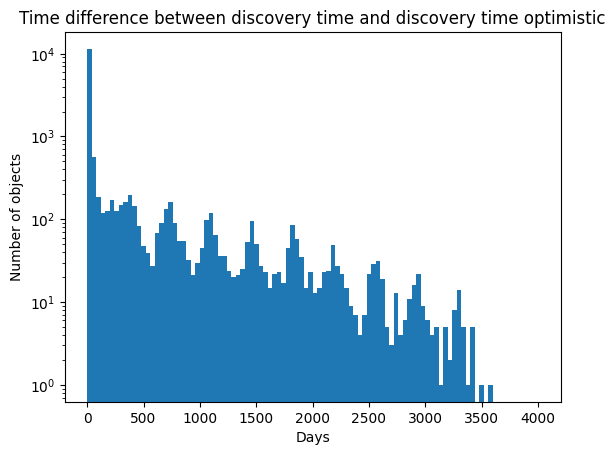

In [131]:
# Now plot a histogram of the time difference
plt.hist(time_diff, bins=100, range=(0, 4000), log=True)
# add titles, xlabel, ylabel
plt.title("Time difference between discovery time and discovery time optimistic")
plt.xlabel("Days")
plt.ylabel("Number of objects")
plt.show()




